In [1]:
import cftime
import pandas as pd
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
from scipy.ndimage import label
from pathlib import Path
import pyarrow as pa
from collections import Counter
import regionmask
import matplotlib.patheffects as path_effects 
import cartopy.io.shapereader as shpreader
import seaborn as sns
from scipy import stats

# Ticks and Plot Features

In [2]:
import numpy as np

def generate_custom_ticks_1(grid_values):
    # 1. Get exact data limits
    exact_min = np.nanmin(grid_values)
    exact_max = np.nanmax(grid_values)
    
    if np.isnan(exact_min): 
        exact_min, exact_max = -7.0, 7.0
        
    # 2. Find the largest absolute value to force symmetry around 0
    max_abs = int(np.ceil(max(abs(exact_min), abs(exact_max))))
    
    # Force a minimum symmetric boundary (e.g., if max change is only 1, force a clean map)
    if max_abs == 0: 
        max_abs = 1
        
    # 3. Establish symmetric exact visual boundaries for pcolormesh (vmin / vmax)
    exact_min_sym = -max_abs
    exact_max_sym = max_abs
    
    # 4. Generate whole-number ticks from -max_abs to +max_abs
    # We step by 1 or 2 depending on how wide the span is to keep the colorbar clean
    step = 1
    custom_ticks = list(range(-max_abs, max_abs + 1, step))
    
    # 5. Create clean string labels without decimal points
    tick_labels = [f"{t}" for t in custom_ticks]
    
    return custom_ticks, tick_labels, exact_max_sym, exact_min_sym

In [3]:
import numpy as np

def generate_custom_ticks_05(grid_values):
    # 1. Get exact data limits
    exact_min = np.nanmin(grid_values)
    exact_max = np.nanmax(grid_values)
    
    if np.isnan(exact_min): 
        exact_min, exact_max = 0.0, 2.0
    
    # 2. Round outward to the nearest 0.25 step to establish the uniform grid
    grid_start = np.floor(exact_min * 4) / 4
    grid_end = np.ceil(exact_max * 4) / 4
    
    # 3. Generate the full uniform step array (inclusive of grid_end) with 0.25 step size
    full_grid = np.arange(grid_start, grid_end + 0.125, 0.25)
    
    # 4. Slice off the fake outer boundaries to leave only the true middle ticks
    middle_ticks = list(full_grid[1:-1])
    
    # 5. Group together middle ticks
    custom_ticks = middle_ticks
    
    # 6. Generate text labels with 2 decimal places (0.00 format)
    tick_labels = [f"{t:.2f}" for t in middle_ticks]
            
    return custom_ticks, tick_labels, exact_max, exact_min

In [4]:
import numpy as np

def generate_custom_ticks_02(grid_values):
    # 1. Get exact data limits
    exact_max = np.nanmax(grid_values)
    
    # 2. Round outward to the nearest 0.5 step to establish the uniform grid
    grid_start = np.floor(-exact_max * 2) / 2
    grid_end = np.ceil(exact_max * 2) / 2
    
    # 3. Generate the full uniform step array (inclusive of grid_end)
    full_grid = np.arange(grid_start, grid_end + 0.1, .1)
    
    # 4. Slice off the fake outer boundaries to leave only the true middle ticks
    middle_ticks = list(full_grid[1:-1])
    
    # 5. Group together: [Exact Min, Middle Ticks..., Exact Max]
    custom_ticks = [-exact_max] + middle_ticks + [exact_max]
    
    # 6. Generate text labels matching the spacing rules
    tick_labels = []
    for t in custom_ticks:
        if t % 1 == 0:
            tick_labels.append(f"{t:.1f}") # Pure whole numbers get no decimals
        else:
            tick_labels.append(f"{t:.1f}")  # Half-steps get 1 decimal place (e.g., 2.5)
            
    return custom_ticks, tick_labels, exact_max, -exact_max

In [5]:

# --- STEP 1: Load Canada and Mexico Geometries once ---
shpfilename = shpreader.natural_earth(resolution='50m', category='cultural', name='admin_0_countries')
reader = shpreader.Reader(shpfilename)
records = reader.records()

canada_geom = None
mexico_geom = None

for record in records:
    country_name = record.attributes.get('NAME')
    if country_name == 'Canada':
        canada_geom = record.geometry
    elif country_name == 'Mexico':
        mexico_geom = record.geometry

# Load 50m Lakes Shapefile from Natural Earth
lakes_shp = shpreader.natural_earth(resolution='50m', category='physical', name='lakes')
lakes_reader = shpreader.Reader(lakes_shp)

# Names of the Great Lakes to isolate
great_lakes_names = {'Lake Superior', 'Lake Michigan', 'Lake Huron', 'Lake Erie', 'Lake Ontario'}

# Filter out only the Great Lakes geometries
great_lakes_geoms = []
for record in lakes_reader.records():
    # 'name' is the attribute key for the lake's name in Natural Earth
    lake_name = record.attributes.get('name')
    if lake_name in great_lakes_names:
        great_lakes_geoms.append(record.geometry)

# Use Natural Earth's defined regions for US States (50m resolution)
us_states = regionmask.defined_regions.natural_earth_v5_0_0.us_states_50

# HIST/FTR Thirstwave File

In [6]:
# Define file paths
hist = '/data1/michsh/CSV/HIST_derived_metrics_2.csv'
ftr = '/data1/michsh/CSV/FUT_derived_metrics_2.csv'

# Thirstwave Characteristics HIST/FTR AVG

## Intensity

In [7]:
import gc
import numpy as np
import pandas as pd

# Clean up old global variables if re-running in Jupyter
if "hist_dur_events" in globals():
    del hist_int_events
    gc.collect()

if "ftr_dur_events" in globals():
    del ftr_int_events
    gc.collect()

# Added 'start_date' (or 'time') to explicitly identify unique temporal events
cols_to_keep = ["AMOC", "member", "lat", "lon", "mean_intensity", "start_time"]

# ==========================================
# STEP 1: Process HIST Baseline
# ==========================================
hist_int_chunks = []
for chunk in pd.read_csv(hist, chunksize=200000, usecols=cols_to_keep):
    # Filter valid durations and drop local duplicates including start_date
    filtered_chunk = chunk[chunk["mean_intensity"] > 0].drop_duplicates()
    hist_int_chunks.append(filtered_chunk)

hist_int_events = pd.concat(hist_int_chunks, ignore_index=True).drop_duplicates()

# FREE MEMORY: Drop chunk list
del hist_int_chunks
gc.collect()

# Optional: If you don't need start_date for downstream steps, drop it now
# hist_dur_events = hist_dur_events.drop(columns=["start_date"])

# ==========================================
# STEP 2: Process FTR Future
# ==========================================
ftr_int_chunks = []
for chunk in pd.read_csv(ftr, chunksize=200000, usecols=cols_to_keep):
    filtered_chunk = chunk[chunk["mean_intensity"] > 0].drop_duplicates()
    ftr_int_chunks.append(filtered_chunk)

ftr_int_events = pd.concat(ftr_int_chunks, ignore_index=True).drop_duplicates()

# FREE MEMORY: Drop chunk list
del ftr_int_chunks
gc.collect()

# Optional: Drop start_date here as well
# ftr_dur_events = ftr_dur_events.drop(columns=["start_date"])

0

In [8]:
hist_member_means = (
    hist_int_events
    .groupby(['lat', 'lon', 'AMOC', 'member'])['mean_intensity']
    .mean()
    .reset_index()
)

ftr_member_means = (
    ftr_int_events
    .groupby(['lat', 'lon', 'AMOC', 'member'])['mean_intensity']
    .mean()
    .reset_index()
)

# --- 3. Calculate the Mean Across the 80 Ensemble Members ---
# Now we average over the 'AMOC' and 'member' dimensions to get one value per grid box.
hist_ensemble_mean_intensity = (
    hist_member_means
    .groupby(['lat', 'lon'])['mean_intensity']
    .mean()
    .reset_index(name='mean_int')
)

ftr_ensemble_mean_intensity = (
    ftr_member_means
    .groupby(['lat', 'lon'])['mean_intensity']
    .mean()
    .reset_index(name='mean_int')
)

In [22]:
import pandas as pd


def get_conus_mask_df(df, us_states_obj):
    """Generates a DataFrame of valid CONUS lat/lon coordinates from a dataset."""
    lats = df["lat"].unique()
    lons = df["lon"].unique()

    # Generate 3D Fractional CONUS Mask & collapse to 2D
    frac_mask_3d = us_states_obj.mask_3D_frac_approx(lons, lats, wrap_lon=True)
    any_overlap_mask = (frac_mask_3d > 0).any(dim="region")

    # Return unique lat/lon pairs inside CONUS
    return (
        any_overlap_mask.to_dataframe(name="is_conus")
        .query("is_conus == True")
        .reset_index()[["lat", "lon"]]
    )


def slice_spatial_box(df, s=None, n=None, w=None, e=None, conus_mask_df=None):
    """Filters a DataFrame by latitude/longitude bounds and/or a CONUS shape mask."""
    # Start with full copy or CONUS-masked subset
    if conus_mask_df is not None:
        filtered_df = pd.merge(
            df, conus_mask_df, on=["lat", "lon"], how="inner"
        )
    else:
        filtered_df = df.copy()

    # If no spatial box bounds are specified, return the current masked DataFrame
    if s is None or n is None or w is None or e is None:
        return filtered_df

    # Apply bounding box filtering for sub-regions
    w_neg, e_neg = -abs(w), -abs(e)
    w_360, e_360 = w_neg % 360, e_neg % 360

    lat_mask = (filtered_df["lat"] >= s) & (filtered_df["lat"] <= n)
    lon_mask = ((filtered_df["lon"] >= w_neg) & (filtered_df["lon"] <= e_neg)) | (
        (filtered_df["lon"] >= w_360) & (filtered_df["lon"] <= e_360)
    )

    return filtered_df[lat_mask & lon_mask].copy()


# =========================================================================
# 1. PRE-COMPUTE CONUS MASK
# =========================================================================
# Generate CONUS coordinates grid using historical grid structure
conus_coords_df = get_conus_mask_df(hist_ensemble_mean_intensity, us_states)


# =========================================================================
# 2. DEFINE REGIONS CONFIGURATION
# =========================================================================
regions = [
    {
        "name": "CONUS",
        "lat_s": None,
        "lat_n": None,
        "lon_w": None,
        "lon_e": None,
        "use_conus_mask": True,
    },
    {
        "name": "Midwest",
        "lat_s": 39,
        "lat_n": 47,
        "lon_w": -103,
        "lon_e": -89,
        "use_conus_mask": False,  # Set to True if you also want Midwest constrained strictly to CONUS land
    },
    {
        "name": "Northeast",
        "lat_s": 40,
        "lat_n": 45,
        "lon_w": -80,
        "lon_e": -70,
        "use_conus_mask": False,
    },
]


# =========================================================================
# 3. CALCULATE AND PRINT REGIONAL ENSEMBLE MEANS & % CHANGE
# =========================================================================
for reg in regions:
    region_name = reg["name"]
    mask_to_use = conus_coords_df if reg.get("use_conus_mask") else None

    # Slice grid-cell ensemble averages for the region
    hist_reg_df = slice_spatial_box(
        hist_ensemble_mean_intensity,
        reg["lat_s"],
        reg["lat_n"],
        reg["lon_w"],
        reg["lon_e"],
        conus_mask_df=mask_to_use,
    )

    ftr_reg_df = slice_spatial_box(
        ftr_ensemble_mean_intensity,
        reg["lat_s"],
        reg["lat_n"],
        reg["lon_w"],
        reg["lon_e"],
        conus_mask_df=mask_to_use,
    )

    # Calculate scalar spatial mean across grid boxes in the region
    reg_hist_mean = hist_reg_df["mean_int"].mean()
    reg_ftr_mean = ftr_reg_df["mean_int"].mean()

    # Calculate absolute difference (Delta) and Percentage Change
    reg_delta_mean = reg_ftr_mean - reg_hist_mean

    reg_pct_change = (
        (reg_delta_mean / reg_hist_mean) * 100 if reg_hist_mean != 0 else 0.0
    )

    # Print summary output for the current region
    print(f"{'='*60}")
    print(f" REGION: {region_name.upper()}")
    print(f"{'='*60}")
    print(
        f"  Historical Ensemble Mean Intensity: {reg_hist_mean:.4f} mm/day"
    )
    print(
        f"  Future Ensemble Mean Intensity:     {reg_ftr_mean:.4f} mm/day"
    )
    print(
        f"  Net Mean Intensity Change (Delta):  {reg_delta_mean:+.4f} mm/day"
    )
    print(f"  Percentage Change:                  {reg_pct_change:+.2f}%\n")

 REGION: CONUS
  Historical Ensemble Mean Intensity: 1.0769 mm/day
  Future Ensemble Mean Intensity:     1.2746 mm/day
  Net Mean Intensity Change (Delta):  +0.1977 mm/day
  Percentage Change:                  +18.36%

 REGION: MIDWEST
  Historical Ensemble Mean Intensity: 1.6903 mm/day
  Future Ensemble Mean Intensity:     2.0386 mm/day
  Net Mean Intensity Change (Delta):  +0.3482 mm/day
  Percentage Change:                  +20.60%

 REGION: NORTHEAST
  Historical Ensemble Mean Intensity: 0.9431 mm/day
  Future Ensemble Mean Intensity:     1.1543 mm/day
  Net Mean Intensity Change (Delta):  +0.2112 mm/day
  Percentage Change:                  +22.40%



In [23]:
import pandas as pd


def get_conus_mask_df(df, us_states_obj):
    """Generates a DataFrame of valid CONUS lat/lon coordinates from a dataset."""
    lats = df["lat"].unique()
    lons = df["lon"].unique()

    # Generate 3D Fractional CONUS Mask & collapse to 2D
    frac_mask_3d = us_states_obj.mask_3D_frac_approx(lons, lats, wrap_lon=True)
    any_overlap_mask = (frac_mask_3d > 0).any(dim="region")

    # Return unique lat/lon pairs inside CONUS
    return (
        any_overlap_mask.to_dataframe(name="is_conus")
        .query("is_conus == True")
        .reset_index()[["lat", "lon"]]
    )


def slice_spatial_box(df, s=None, n=None, w=None, e=None, conus_mask_df=None):
    """Filters a DataFrame by latitude/longitude bounds and/or a CONUS shape mask."""
    # Start with full copy or CONUS-masked subset
    if conus_mask_df is not None:
        filtered_df = pd.merge(
            df, conus_mask_df, on=["lat", "lon"], how="inner"
        )
    else:
        filtered_df = df.copy()

    # If no spatial box bounds are specified, return the current masked DataFrame
    if s is None or n is None or w is None or e is None:
        return filtered_df

    # Apply bounding box filtering for sub-regions
    w_neg, e_neg = -abs(w), -abs(e)
    w_360, e_360 = w_neg % 360, e_neg % 360

    lat_mask = (filtered_df["lat"] >= s) & (filtered_df["lat"] <= n)
    lon_mask = ((filtered_df["lon"] >= w_neg) & (filtered_df["lon"] <= e_neg)) | (
        (filtered_df["lon"] >= w_360) & (filtered_df["lon"] <= e_360)
    )

    return filtered_df[lat_mask & lon_mask].copy()


# =========================================================================
# 1. PRE-COMPUTE CONUS MASK
# =========================================================================
# Generate CONUS coordinates grid using historical grid structure
conus_coords_df = get_conus_mask_df(hist_ensemble_mean_intensity, us_states)


# =========================================================================
# 2. DEFINE REGIONS CONFIGURATION
# =========================================================================
regions = [
    {
        "name": "CONUS",
        "lat_s": None,
        "lat_n": None,
        "lon_w": None,
        "lon_e": None,
        "use_conus_mask": True,
    },
    {
        "name": "Midwest",
        "lat_s": 39,
        "lat_n": 47,
        "lon_w": -103,
        "lon_e": -89,
        "use_conus_mask": True,  # Set to True if you also want Midwest constrained strictly to CONUS land
    },
    {
        "name": "Northeast",
        "lat_s": 40,
        "lat_n": 45,
        "lon_w": -80,
        "lon_e": -70,
        "use_conus_mask": True,
    },
]


# =========================================================================
# 3. CALCULATE AND PRINT REGIONAL ENSEMBLE MEANS & % CHANGE
# =========================================================================
for reg in regions:
    region_name = reg["name"]
    mask_to_use = conus_coords_df if reg.get("use_conus_mask") else None

    # Slice grid-cell ensemble averages for the region
    hist_reg_df = slice_spatial_box(
        hist_ensemble_mean_intensity,
        reg["lat_s"],
        reg["lat_n"],
        reg["lon_w"],
        reg["lon_e"],
        conus_mask_df=mask_to_use,
    )

    ftr_reg_df = slice_spatial_box(
        ftr_ensemble_mean_intensity,
        reg["lat_s"],
        reg["lat_n"],
        reg["lon_w"],
        reg["lon_e"],
        conus_mask_df=mask_to_use,
    )

    # Calculate scalar spatial mean across grid boxes in the region
    reg_hist_mean = hist_reg_df["mean_int"].mean()
    reg_ftr_mean = ftr_reg_df["mean_int"].mean()

    # Calculate absolute difference (Delta) and Percentage Change
    reg_delta_mean = reg_ftr_mean - reg_hist_mean

    reg_pct_change = (
        (reg_delta_mean / reg_hist_mean) * 100 if reg_hist_mean != 0 else 0.0
    )

    # Print summary output for the current region
    print(f"{'='*60}")
    print(f" REGION: {region_name.upper()}")
    print(f"{'='*60}")
    print(
        f"  Historical Ensemble Mean Intensity: {reg_hist_mean:.4f} mm/day"
    )
    print(
        f"  Future Ensemble Mean Intensity:     {reg_ftr_mean:.4f} mm/day"
    )
    print(
        f"  Net Mean Intensity Change (Delta):  {reg_delta_mean:+.4f} mm/day"
    )
    print(f"  Percentage Change:                  {reg_pct_change:+.2f}%\n")

 REGION: CONUS
  Historical Ensemble Mean Intensity: 1.0769 mm/day
  Future Ensemble Mean Intensity:     1.2746 mm/day
  Net Mean Intensity Change (Delta):  +0.1977 mm/day
  Percentage Change:                  +18.36%

 REGION: MIDWEST
  Historical Ensemble Mean Intensity: 1.6903 mm/day
  Future Ensemble Mean Intensity:     2.0386 mm/day
  Net Mean Intensity Change (Delta):  +0.3482 mm/day
  Percentage Change:                  +20.60%

 REGION: NORTHEAST
  Historical Ensemble Mean Intensity: 0.9497 mm/day
  Future Ensemble Mean Intensity:     1.1700 mm/day
  Net Mean Intensity Change (Delta):  +0.2203 mm/day
  Percentage Change:                  +23.20%



In [ ]:
# ============================================================
#  REGION: CONUS
# ============================================================
#   Historical Ensemble Mean Intensity: 1.0769 mm/day
#   Future Ensemble Mean Intensity:     1.2746 mm/day
#   Net Mean Intensity Change (Delta):  +0.1977 mm/day
#   Percentage Change:                  +18.36%

# ============================================================
#  REGION: MIDWEST
# ============================================================
#   Historical Ensemble Mean Intensity: 1.6903 mm/day
#   Future Ensemble Mean Intensity:     2.0386 mm/day
#   Net Mean Intensity Change (Delta):  +0.3482 mm/day
#   Percentage Change:                  +20.60%

# ============================================================
#  REGION: NORTHEAST
# ============================================================
#   Historical Ensemble Mean Intensity: 0.9497 mm/day
#   Future Ensemble Mean Intensity:     1.1700 mm/day
#   Net Mean Intensity Change (Delta):  +0.2203 mm/day
#   Percentage Change:                  +23.20%



# Intensity: CONUS AVG

In [11]:
masked_data_arrays = []
for df in [hist_ensemble_mean_intensity, ftr_ensemble_mean_intensity]:
    # Extract coordinates
    lats = df['lat'].unique()
    lons = df['lon'].unique()
    
    # 1. Calculate the fractional overlap of each grid cell with the US States.
    # We pass the 1D lat/lon coordinates directly to the fractional mask generator
    frac_mask_3d = us_states.mask_3D_frac_approx(lons, lats, wrap_lon=True)
    
    # 2. Collapse the 'region' dimension by checking if a cell overlaps with ANY US State.
    # We set the threshold to > 0 to keep any cell that touches or sits on the border.
    any_overlap_mask = (frac_mask_3d > 0).any(dim="region")
    
    # 3. Pivot dataframe to apply spatial mask
    pivoted = df.pivot(index='lat', columns='lon', values='mean_int')
    
    # 4. Mask the pivoted data using our fractional boolean mask
    # (Because any_overlap_mask is an xarray DataArray, we extract its values using .values)
    pivoted_masked = pivoted.where(any_overlap_mask.values)
    
    # 5. Flatten/melt back into the clean flat DataFrame format
    flat_masked = (
        pivoted_masked
        .stack(dropna=True) # Drops all grid coordinates outside CONUS
        .reset_index(name='mean_int')
    )
    masked_data_arrays.append(flat_masked)

hist_ensemble_mean_intensity_masked, ftr_ensemble_mean_intensity_masked = masked_data_arrays

/tmp/ipykernel_1257508/2097711760.py:24: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  pivoted_masked
/tmp/ipykernel_1257508/2097711760.py:24: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  pivoted_masked


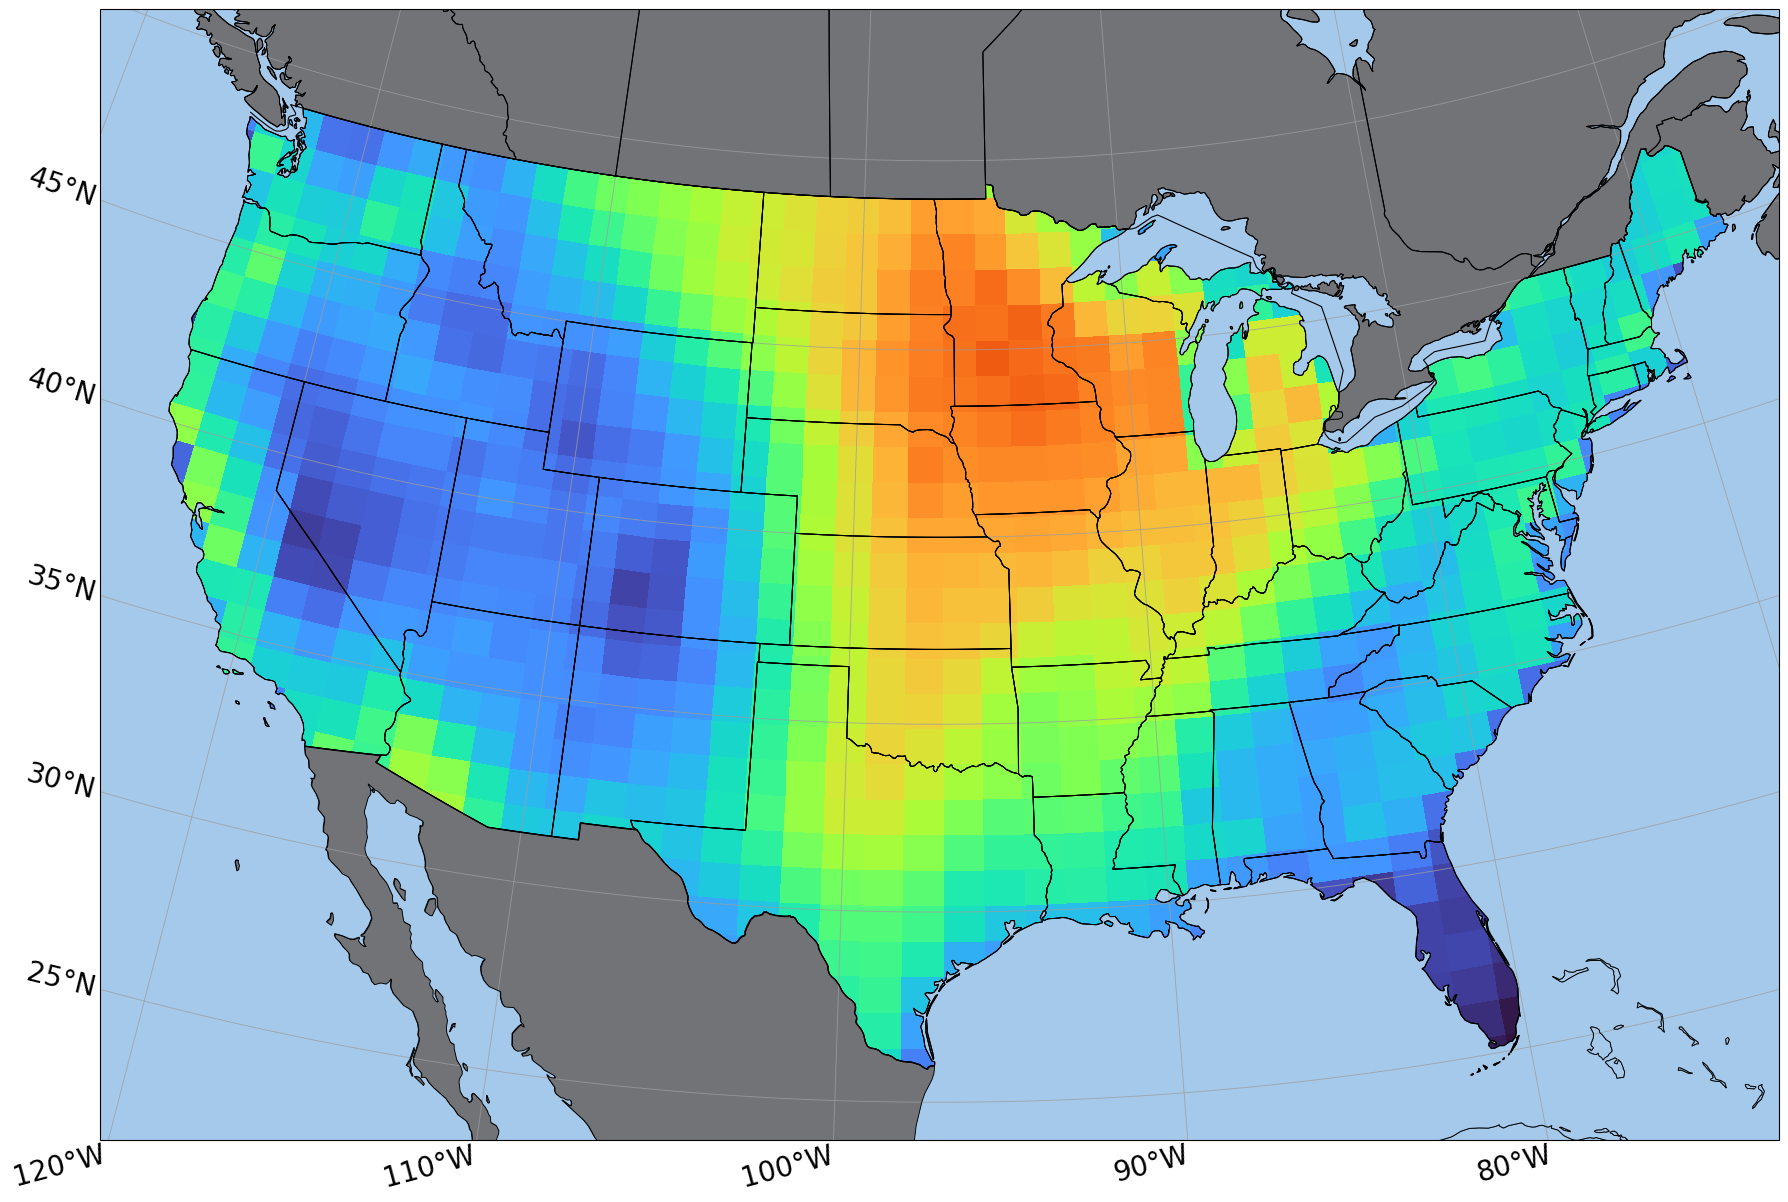

In [12]:
# Reassign masked datasets
hist_conus_mean_masked, ftr_conus_mean_masked = masked_data_arrays

data_arrays = [hist_ensemble_mean_intensity_masked]

global_min = min(hist_conus_mean_masked['mean_int'].min(), ftr_conus_mean_masked['mean_int'].min())
global_max = max(hist_conus_mean_masked['mean_int'].max(), ftr_conus_mean_masked['mean_int'].max())

combined_min_max_grid = np.array([global_min, global_max])
custom_ticks, tick_labels, exact_max, exact_min = generate_custom_ticks_05(combined_min_max_grid)

for array in data_arrays: 
    plot_target_da = array  

    if plot_target_da is hist_ensemble_mean_intensity_masked:
        title = "Historical Thirstwave Intensity | 80-Member Ensemble Mean"
        cb_label = "Days"
        save_name = 'Intensity_Mean_HIST'
    elif plot_target_da is ftr_ensemble_mean_intensity_masked:
        title = "Future Thirstwave Intensity | 80-Member Ensemble Mean"
        cb_label = "Days"
        save_name = 'Intensity_Mean_FTR'

    # This transforms the flat DataFrame into a clean 2D grid of values
    grid_data_int = (
        plot_target_da
        .pivot(index='lat', columns='lon', values='mean_int')
        .sort_index(ascending=True)         # Sort Latitudes monotonically
        .sort_index(axis=1, ascending=True) # Sort Longitudes monotonically
    )

    # Create Meshgrid from sorted 1D coordinates
    X, Y = np.meshgrid(grid_data_int.columns, grid_data_int.index)

    s_lat, n_lat = 24, 52
    w_lon, e_lon = -121, -73

    crs = ccrs.LambertConformal(central_longitude=-97, central_latitude=40)

    fig = plt.figure(figsize=(18, 16))
    ax = plt.axes(projection=crs)

    # Set map boundaries
    ax.set_extent([w_lon, e_lon, s_lat, n_lat], crs=ccrs.PlateCarree())  

    water_color = '#a5c9eb'  # Soft pastel blue
    ax.set_facecolor(water_color)  

    im = ax.pcolormesh(X, Y, grid_data_int.values, 
                        transform=ccrs.PlateCarree(), 
                        cmap='turbo', # <==================================================================== COLORTABLE
                        vmin=exact_min, vmax=exact_max, 
                        shading='auto',
                        zorder=1)

    if canada_geom is not None:
        ax.add_geometries([canada_geom], crs=ccrs.PlateCarree(), 
                            facecolor='#717376', edgecolor='black', linewidth=0.65, zorder=2)
    if mexico_geom is not None:
        ax.add_geometries([mexico_geom], crs=ccrs.PlateCarree(), 
                            facecolor="#717376", edgecolor='black', linewidth=0.65, zorder=2)
    if great_lakes_geoms:
        ax.add_geometries(great_lakes_geoms, crs=ccrs.PlateCarree(),
                            facecolor=water_color, edgecolor='black', linewidth=0.65, zorder=2)

    # USA outer outline
    ax.add_feature(cfeature.OCEAN.with_scale('50m'), facecolor=water_color, zorder=2)
    ax.coastlines('50m', linewidth=0.65, color='black', zorder=3)

    # USA outer outline
    usa_outline = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_0_boundary_lines_land',
        scale='50m',
        facecolor='none',
        edgecolor='black',
        linewidth=0.8
    )
    ax.add_feature(usa_outline, zorder=3)

    # US State Boundaries
    states = cfeature.NaturalEarthFeature(
        category='cultural', 
        name='admin_1_states_provinces_lakes', 
        scale='50m', 
        facecolor='none'
    )
    ax.add_feature(states, edgecolor='black', linewidth=0.75, zorder=3)

    # Map features
    ax.coastlines('50m', linewidth=0.65)
    states = cfeature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')
    ax.add_feature(states, edgecolor='black', linewidth=0.65)

        # Drawing gridlines
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.65, 
                        color="#9d9d9d", zorder= 4, alpha=0.8)

    # Restrict labels to ONLY the bottom and left
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = True
    gl.left_labels = True

    gl.x_inline = False
    gl.y_inline = False

    # --- ADDED: Set padding (in points) between labels and the map frame ---
    gl.xpadding = 4  # Adds space for bottom (longitude) labels
    gl.ypadding = 4  # Adds space for left (latitude) labels

    # Style the labels (removed the non-standard 'pad' key)
    gl.xlabel_style = {'size': 20, 'color': 'black', 'rotation': 15}
    gl.ylabel_style = {'size': 20, 'color': 'black'}

    # Force clean tick intervals
    gl.xlocator = mticker.FixedLocator(range(-130, -60, 10))
    gl.ylocator = mticker.FixedLocator(range(20, 55, 5))
    
    # ax_box = ax.inset_axes([0.90, 0, 0.10, 0.55], zorder=5)
    # ax_box.set_facecolor('white')
    # ax_box.set_xticks([])
    # ax_box.set_yticks([])
    # for spine in ax_box.spines.values():
    #     spine.set_visible(True)
    #     spine.set_edgecolor('black')
    #     spine.set_linewidth(1.0)

    # # Adjusted to end at y=0.78, leaving the top 22% of the white box for the title
    # # Pushed to x=0.20 to leave plenty of room on the right side for tick labels
    # cax = ax_box.inset_axes([0.10, 0.04, 0.44, 0.84]) 

    # # Plot vertical colorbar (Notice: cb.ax.set_title was removed!)
    # cb = plt.colorbar(im, cax=cax, orientation='vertical', ticks=custom_ticks) 

    # # Style the colorbar ticks & tick labels
    # cb.ax.set_yticklabels(tick_labels, fontsize=18, color='black')
    # cb.ax.tick_params(direction='out', length=4, width=1)

    # # --- ADDED: Text Title inside the White Box ---
    # # Centered at x=0.5 (middle of the box) and y=0.89 (near the top)
    # ax_box.text(
    #     0.5, 0.94, 
    #     "Days", 
    #     transform=ax_box.transAxes, 
    #     fontsize=20, 
    #     weight='bold', 
    #     color='black',
    #     ha='center', 
    #     va='center'
    # )

    # Title & Layout rendering
    plt.tight_layout()

    plt.savefig(save_name, dpi=300, bbox_inches='tight')
    plt.show()  

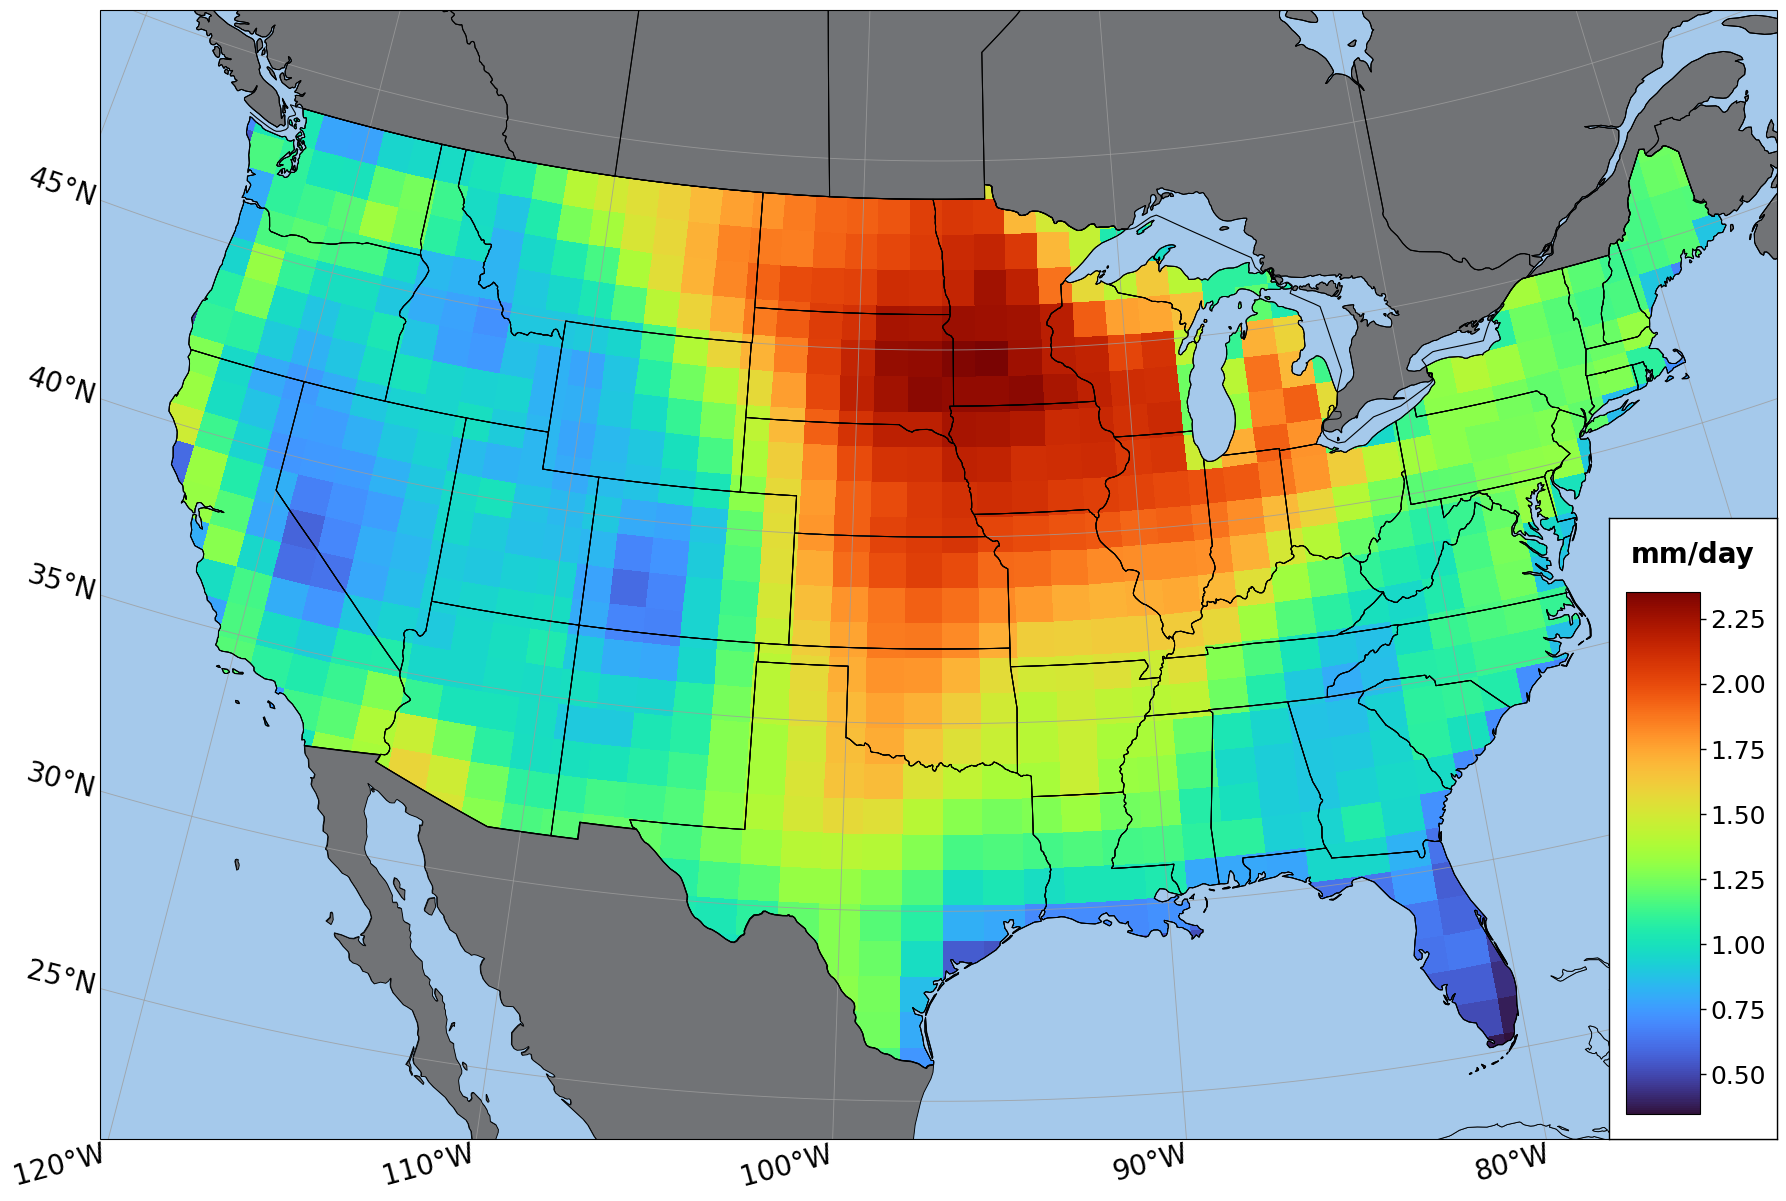

In [13]:
# Reassign masked datasets
hist_conus_mean_masked, ftr_conus_mean_masked = masked_data_arrays

data_arrays = [ftr_ensemble_mean_intensity_masked]

global_min = min(hist_conus_mean_masked['mean_int'].min(), ftr_conus_mean_masked['mean_int'].min())
global_max = max(hist_conus_mean_masked['mean_int'].max(), ftr_conus_mean_masked['mean_int'].max())

combined_min_max_grid = np.array([global_min, global_max])
custom_ticks, tick_labels, exact_max, exact_min = generate_custom_ticks_05(combined_min_max_grid)

for array in data_arrays: 
    plot_target_da = array  

    if plot_target_da is hist_ensemble_mean_intensity_masked:
        title = "Historical Thirstwave Intensity | 80-Member Ensemble Mean"
        cb_label = "Days"
        save_name = 'Intensity_Mean_HIST'
    elif plot_target_da is ftr_ensemble_mean_intensity_masked:
        title = "Future Thirstwave Intensity | 80-Member Ensemble Mean"
        cb_label = "Days"
        save_name = 'Intensity_Mean_FTR'

    # This transforms the flat DataFrame into a clean 2D grid of values
    grid_data_int = (
        plot_target_da
        .pivot(index='lat', columns='lon', values='mean_int')
        .sort_index(ascending=True)         # Sort Latitudes monotonically
        .sort_index(axis=1, ascending=True) # Sort Longitudes monotonically
    )

    # Create Meshgrid from sorted 1D coordinates
    X, Y = np.meshgrid(grid_data_int.columns, grid_data_int.index)

    s_lat, n_lat = 24, 52
    w_lon, e_lon = -121, -73

    crs = ccrs.LambertConformal(central_longitude=-97, central_latitude=40)

    fig = plt.figure(figsize=(18, 16))
    ax = plt.axes(projection=crs)

    # Set map boundaries
    ax.set_extent([w_lon, e_lon, s_lat, n_lat], crs=ccrs.PlateCarree())  

    water_color = '#a5c9eb'  # Soft pastel blue
    ax.set_facecolor(water_color)  

    im = ax.pcolormesh(X, Y, grid_data_int.values, 
                       transform=ccrs.PlateCarree(), 
                       cmap='turbo', 
                       vmin=exact_min, vmax=exact_max, 
                       shading='auto',
                       zorder=1)

    if canada_geom is not None:
        ax.add_geometries([canada_geom], crs=ccrs.PlateCarree(), 
                          facecolor='#717376', edgecolor='black', linewidth=0.65, zorder=2)
    if mexico_geom is not None:
        ax.add_geometries([mexico_geom], crs=ccrs.PlateCarree(), 
                          facecolor="#717376", edgecolor='black', linewidth=0.65, zorder=2)
    if great_lakes_geoms:
        ax.add_geometries(great_lakes_geoms, crs=ccrs.PlateCarree(),
                          facecolor=water_color, edgecolor='black', linewidth=0.65, zorder=2)

    # USA outer outline
    ax.add_feature(cfeature.OCEAN.with_scale('50m'), facecolor=water_color, zorder=2)
    ax.coastlines('50m', linewidth=0.65, color='black', zorder=3)

    # USA outer outline
    usa_outline = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_0_boundary_lines_land',
        scale='50m',
        facecolor='none',
        edgecolor='black',
        linewidth=0.8
    )
    ax.add_feature(usa_outline, zorder=3)

    # US State Boundaries
    states = cfeature.NaturalEarthFeature(
        category='cultural', 
        name='admin_1_states_provinces_lakes', 
        scale='50m', 
        facecolor='none'
    )
    ax.add_feature(states, edgecolor='black', linewidth=0.75, zorder=3)

    # Map features
    ax.coastlines('50m', linewidth=0.65)
    states = cfeature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')
    ax.add_feature(states, edgecolor='black', linewidth=0.65)

        # Drawing gridlines
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.65, 
                      color="#9d9d9d", zorder= 4, alpha=0.8)

    # Restrict labels to ONLY the bottom and left
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = True
    gl.left_labels = True

    gl.x_inline = False
    gl.y_inline = False

    # --- ADDED: Set padding (in points) between labels and the map frame ---
    gl.xpadding = 4  # Adds space for bottom (longitude) labels
    gl.ypadding = 4  # Adds space for left (latitude) labels

    # Style the labels (removed the non-standard 'pad' key)
    gl.xlabel_style = {'size': 20, 'color': 'black', 'rotation': 15}
    gl.ylabel_style = {'size': 20, 'color': 'black'}

    # Force clean tick intervals
    gl.xlocator = mticker.FixedLocator(range(-130, -60, 10))
    gl.ylocator = mticker.FixedLocator(range(20, 55, 5))
    
    ax_box = ax.inset_axes([0.90, 0, 0.10, 0.55], zorder=5)
    ax_box.set_facecolor('white')
    ax_box.set_xticks([])
    ax_box.set_yticks([])
    for spine in ax_box.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('black')
        spine.set_linewidth(1.0)

    # Adjusted to end at y=0.78, leaving the top 22% of the white box for the title
    # Pushed to x=0.20 to leave plenty of room on the right side for tick labels
    cax = ax_box.inset_axes([0.10, 0.04, 0.44, 0.84]) 

    # Plot vertical colorbar (Notice: cb.ax.set_title was removed!)
    cb = plt.colorbar(im, cax=cax, orientation='vertical', ticks=custom_ticks) 

    # Style the colorbar ticks & tick labels
    cb.ax.set_yticklabels(tick_labels, fontsize=18, color='black')
    cb.ax.tick_params(direction='out', length=4, width=1)

    # --- ADDED: Text Title inside the White Box ---
    # Centered at x=0.5 (middle of the box) and y=0.89 (near the top)
    ax_box.text(
        0.5, 0.94, 
        "mm/day", 
        transform=ax_box.transAxes, 
        fontsize=20, 
        weight='bold', 
        color='black',
        ha='center', 
        va='center'
    )

    # Title & Layout rendering
    plt.tight_layout()

    plt.savefig(save_name, dpi=300, bbox_inches='tight')
    plt.show()  

# Intensity: Pooled T-Test + Delta

In [14]:
from scipy import stats

# ==========================================
# STEP 1: Grid-by-Grid Loop across Ensemble Members
# ==========================================
# Extract unique spatial grid boxes from duration data
int_gridboxes = hist_member_means[["lat", "lon"]].drop_duplicates()
int_results = []

for row in int_gridboxes.itertuples():
    lat = row.lat
    lon = row.lon

    # Extract all ~80 ensemble members (AMOC x member) for this specific lat/lon
    int_hist_subset = hist_member_means[
        (hist_member_means.lat == lat) & (hist_member_means.lon == lon)
    ]
    int_ftr_subset = ftr_member_means[
        (ftr_member_means.lat == lat) & (ftr_member_means.lon == lon)
    ]

    int_hist_values = int_hist_subset["mean_intensity"].values
    int_ftr_values = int_ftr_subset["mean_intensity"].values

    # Run independent t-test across ensemble members
    int_t_stat, int_p_value = stats.ttest_ind(
        int_ftr_values,
        int_hist_values,
        equal_var=True,
        alternative="greater",  # Testing if FTR duration > HIST duration
        nan_policy="omit",
    )

    # Calculate difference between future ensemble mean and historical ensemble mean
    int_delta_value = np.nanmean(int_ftr_values) - np.nanmean(int_hist_values)

    int_results.append([lat, lon, int_p_value, int_delta_value])

# Create flat DataFrame of raw results
int_results_df = pd.DataFrame(
    int_results, columns=["lat", "lon", "p_value", "delta"]
)

# ==========================================
# STEP 2: Pivot into Lat x Lon Matrices
# ==========================================
int_p_values_grid = int_results_df.pivot(
    index="lat", columns="lon", values="p_value"
)
int_delta_grid = int_results_df.pivot(
    index="lat", columns="lon", values="delta"
)

# ==========================================
# STEP 3: Apply CONUS Spatial Mask
# ==========================================
int_lats = int_p_values_grid.index.values
int_lons = int_p_values_grid.columns.values

frac_mask_3d = us_states.mask_3D_frac_approx(int_lons, int_lats, wrap_lon=True)
any_overlap_mask = (frac_mask_3d > 0).any(dim="region")

# Mask both duration matrices to CONUS
int_p_values_mask = int_p_values_grid.where(any_overlap_mask.values)
int_delta_mask = int_delta_grid.where(any_overlap_mask.values)

# ==========================================
# STEP 4: Unstack & Summarize Results
# ==========================================
# Flat DataFrames ready for plotting or exporting
int_p_values_conus_flat = (
    int_p_values_mask.stack(future_stack=True)
    .dropna()
    .reset_index(name="p_value")
)

int_delta_conus_flat = (
    int_delta_mask.stack(future_stack=True)
    .dropna()
    .reset_index(name="delta")
)

# Percentage of CONUS grid cells with statistically significant increase in duration (p < 0.05)
total_conus_cells = int_p_values_mask.notna().sum().sum()
significant_conus_cells = (int_p_values_mask < 0.05).sum().sum()

sig_pct_dur = (significant_conus_cells / total_conus_cells) * 100
print(
    f"Percentage of CONUS showing significant intensity increase (p < 0.05): {sig_pct_dur:.2f}%"
)

Percentage of CONUS showing significant intensity increase (p < 0.05): 95.28%


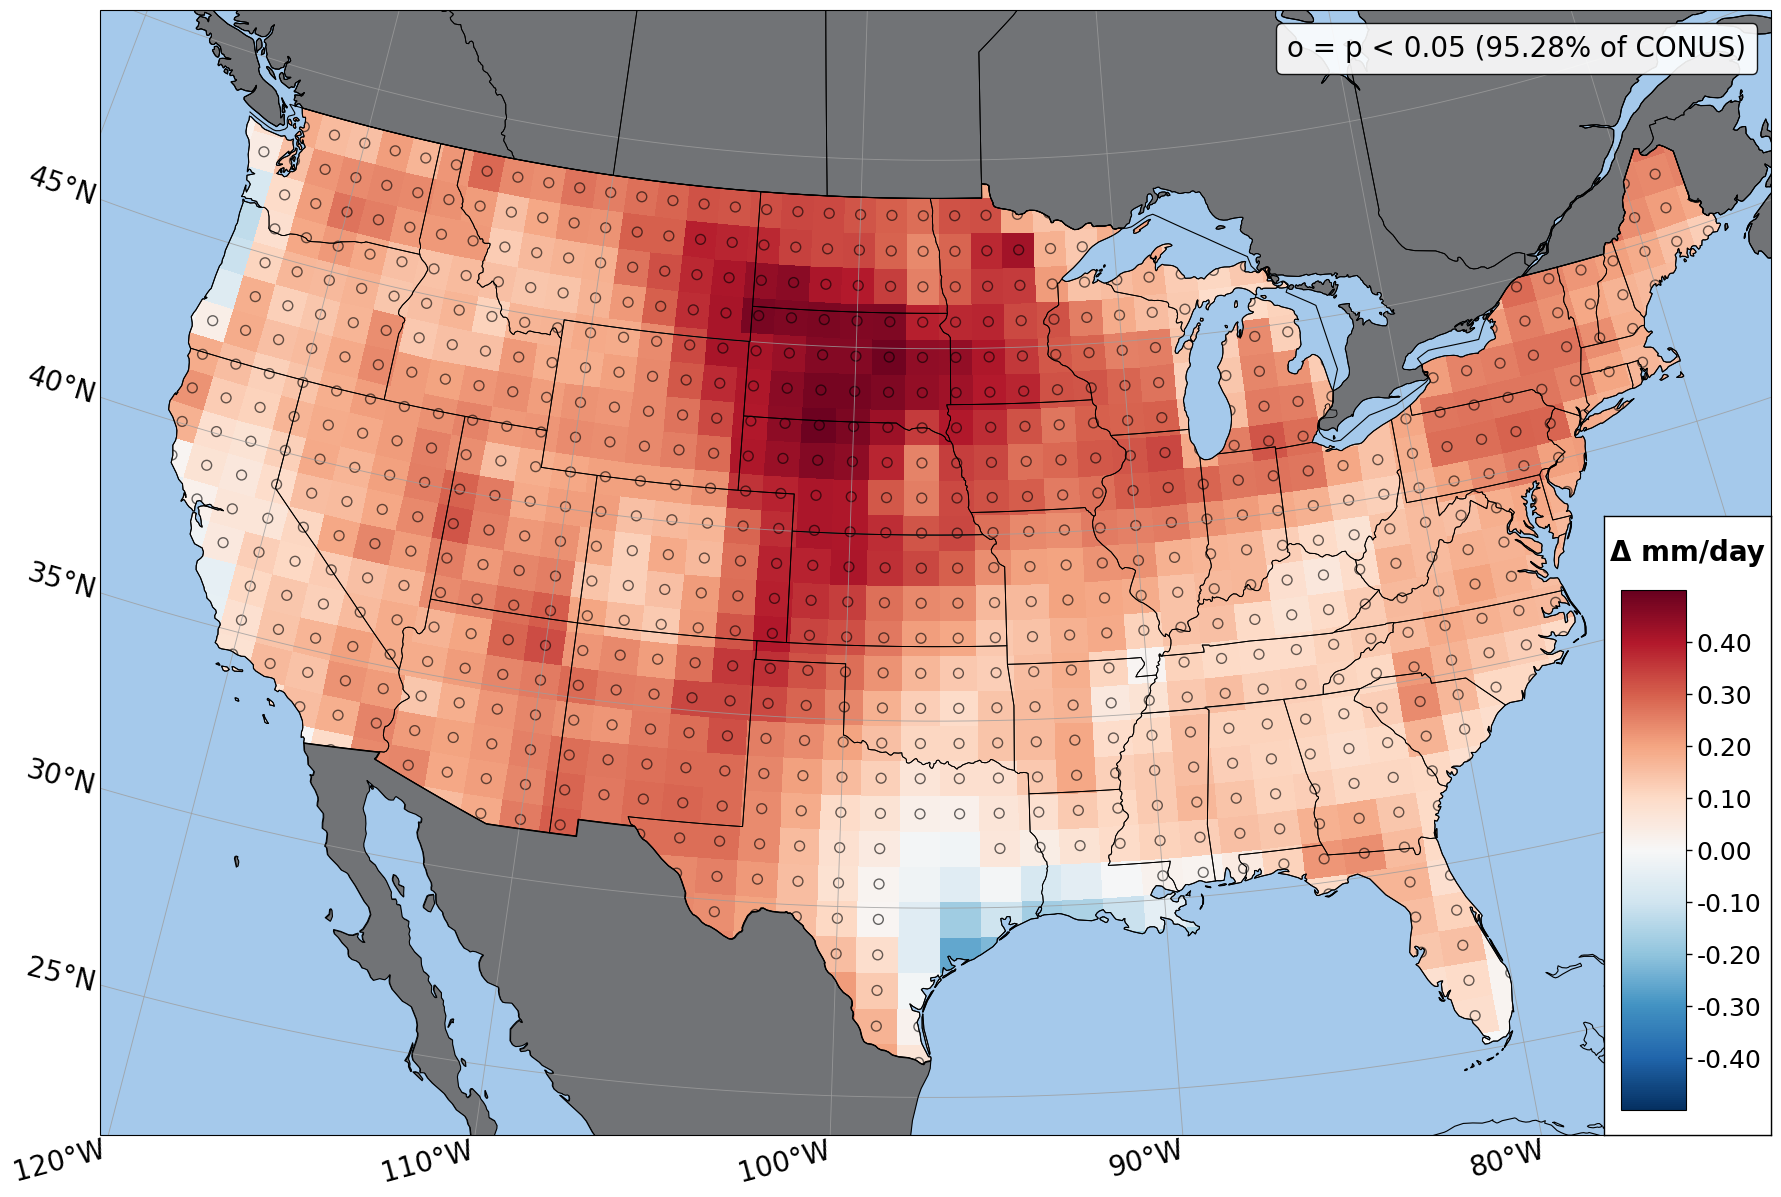

In [15]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from matplotlib.lines import Line2D


# ==========================================
# 0. Custom Colorbar Tick Generator Function
# ==========================================
def generate_custom_ticks_1(grid_values, step=0.1):
    """Computes exact data min/max within CONUS, symmetric limits for pcolormesh,

    and ticks spaced by 'step', explicitly including the exact min value while
    excluding the maximum value from the tick marks.
    """
    exact_min = float(np.nanmin(grid_values))
    exact_max = float(np.nanmax(grid_values))

    if np.isnan(exact_min):
        exact_min, exact_max = -1.0, 1.0

    # Symmetric limits rounded up to the nearest multiple of 'step'
    max_abs = np.ceil(max(abs(exact_min), abs(exact_max)) / step) * step
    if max_abs == 0:
        max_abs = step

    exact_min_sym = -max_abs
    exact_max_sym = max_abs

    # Generate potential ticks in increments of 'step'
    num_steps = int(np.round((exact_max_sym - exact_min_sym) / step)) + 1
    all_possible_ticks = np.round(
        np.linspace(exact_min_sym, exact_max_sym, num_steps), 2
    )

    # Filter ticks strictly within (exact_min, exact_max)
    custom_ticks = [
        t for t in all_possible_ticks if exact_min < t < exact_max
    ]

    # Explicitly include exact minimum and 0 if within bounds
    for required_val in [exact_min, 0.0]:
        if exact_min < required_val < exact_max:
            if not any(
                np.isclose(required_val, t, atol=1e-4) for t in custom_ticks
            ):
                custom_ticks.append(required_val)

    # Sort ticks and clean up float precision
    custom_ticks = sorted(list(np.round(custom_ticks, 2)))
    tick_labels = [f"{t:.2f}" for t in custom_ticks]

    return (
        custom_ticks,
        tick_labels,
        exact_max_sym,
        exact_min_sym,
        exact_min,
        exact_max,
    )


# ==========================================
# 1. Color Bar Ticks Settings (Intensity)
# ==========================================
int_CONUS_max = np.nanmax(np.abs(int_delta_mask.values))
int_CONUS_min = -int_CONUS_max

combined_min_max_grid = np.array([int_CONUS_min, int_CONUS_max])

# Call custom tick generator (adjust step size here if needed)
(
    custom_ticks,
    tick_labels,
    exact_max,
    exact_min,
    exact_min_data,
    exact_max_data,
) = generate_custom_ticks_1(combined_min_max_grid, step=0.1)

alpha = 0.05

# ==========================================
# 2. Statistically Significant Gridcells Mask
# ==========================================
# Identifies grid cells where intensity increased significantly (p < 0.05)
stat_sig_mask = (int_p_values_mask < alpha) & (int_delta_mask > 0)

# Calculate percentage of CONUS experiencing significant intensity increase
total_conus_cells = int_p_values_mask.notna().sum().sum()
significant_conus_cells = stat_sig_mask.sum().sum()

sig_pct = (significant_conus_cells / total_conus_cells) * 100

# ==========================================
# 3. Coordinate Grids & Extracted Stippling Points
# ==========================================
X, Y = np.meshgrid(int_delta_mask.columns, int_delta_mask.index)

# Extract coordinates for stippling where stat_sig_mask is True
sig_y_indices, sig_x_indices = np.where(stat_sig_mask.values)
significant_lats = int_delta_mask.index[sig_y_indices]
significant_lons = int_delta_mask.columns[sig_x_indices]

# ==========================================
# 4. Figure & Projection Setup
# ==========================================
s_lat, n_lat = 24, 52
w_lon, e_lon = -121, -73

crs = ccrs.LambertConformal(central_longitude=-97, central_latitude=40)

fig = plt.figure(figsize=(18, 16))
ax = plt.axes(projection=crs)

ax.set_extent([w_lon, e_lon, s_lat, n_lat], crs=ccrs.PlateCarree())

water_color = "#a5c9eb"
ax.set_facecolor(water_color)

# Plot the intensity delta background field
im = ax.pcolormesh(
    X,
    Y,
    int_delta_mask.values,
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    vmin=exact_min,
    vmax=exact_max,
    shading="auto",
    zorder=1,
)

# Geographic overlays
if canada_geom is not None:
    ax.add_geometries(
        [canada_geom],
        crs=ccrs.PlateCarree(),
        facecolor="#717376",
        edgecolor="black",
        linewidth=0.8,
        zorder=2,
    )
if mexico_geom is not None:
    ax.add_geometries(
        [mexico_geom],
        crs=ccrs.PlateCarree(),
        facecolor="#717376",
        edgecolor="black",
        linewidth=0.8,
        zorder=2,
    )
if great_lakes_geoms:
    ax.add_geometries(
        great_lakes_geoms,
        crs=ccrs.PlateCarree(),
        facecolor=water_color,
        edgecolor="black",
        linewidth=0.75,
        zorder=2,
    )

ax.add_feature(
    cfeature.OCEAN.with_scale("50m"), facecolor=water_color, zorder=2
)
ax.coastlines("50m", linewidth=0.8, color="black", zorder=4)

usa_outline = cfeature.NaturalEarthFeature(
    category="cultural",
    name="admin_0_boundary_lines_land",
    scale="50m",
    facecolor="none",
    edgecolor="black",
    linewidth=0.8,
    zorder=4,
)
ax.add_feature(usa_outline, zorder=3)

states = cfeature.NaturalEarthFeature(
    category="cultural",
    name="admin_1_states_provinces_lakes",
    scale="50m",
    facecolor="none",
)
ax.add_feature(states, edgecolor="black", linewidth=0.65, zorder=4)

# Gridlines styling (Font size 20pt)
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.65,
    color="#9d9d9d",
    alpha=0.8,
    zorder=5,
)

gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = True
gl.left_labels = True
gl.x_inline = False
gl.y_inline = False
gl.xpadding = 4
gl.ypadding = 4

gl.xlabel_style = {"size": 20, "color": "black", "rotation": 15}
gl.ylabel_style = {"size": 20, "color": "black"}

gl.xlocator = mticker.FixedLocator(range(-130, -60, 10))
gl.ylocator = mticker.FixedLocator(range(20, 55, 5))

# ==========================================
# 5. Significance Legend Box
# ==========================================
legend_label = f"o = p < 0.05 ({sig_pct:.2f}% of CONUS)"

proxy_handle = Line2D(
    [0],
    [0],
    color="none",
    linestyle="none",
    marker="none",
    label=legend_label,
)

leg = ax.legend(
    handles=[proxy_handle],
    loc="upper right",
    frameon=True,
    facecolor="white",
    framealpha=0.9,
    edgecolor="black",
    fontsize=20,
    handlelength=0,
    handletextpad=0,
)
leg.set_zorder(6)

# ==========================================
# 6. Colorbar Inset Box
# ==========================================
ax_box = ax.inset_axes([0.90, 0, 0.10, 0.55], zorder=6)
ax_box.set_facecolor("white")
ax_box.set_xticks([])
ax_box.set_yticks([])
for spine in ax_box.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor("black")
    spine.set_linewidth(1.0)

cax = ax_box.inset_axes([0.10, 0.04, 0.39, 0.84])
cb = plt.colorbar(im, cax=cax, orientation="vertical", ticks=custom_ticks)

cb.ax.set_yticklabels(tick_labels, fontsize=18, color="black")
cb.ax.tick_params(direction="out", length=4, width=1)

# Inset box label
ax_box.text(
    0.5,
    0.94,
    "Δ mm/day",
    transform=ax_box.transAxes,
    fontsize=20,
    weight="bold",
    color="black",
    ha="center",
    va="center",
)

# ==========================================
# 7. Significance Stippling Overlay & Output
# ==========================================
ax.scatter(
    significant_lons,
    significant_lats,
    transform=ccrs.PlateCarree(),
    s=50,
    marker="o",
    facecolors="none",
    edgecolors="black",
    alpha=0.6,
    zorder=1.5,
)

plt.tight_layout()

plt.savefig("Intensity_Mean_Delta_005.png", dpi=300, bbox_inches="tight")
plt.show()

# Duration: Histograms

In [16]:
# ==============================================================================
# Pre-Histogram Processing for Event Durations (CONUS Masking)
# ==============================================================================

masked_int_arrays = []

# Process both datasets directly from the loaded event DataFrames
intensity_datasets = [hist_int_events, ftr_int_events]

for df_int in intensity_datasets:
    # -------------------------------------------------------------------------
    # STEP 1: Extract Spatial Coordinates
    # -------------------------------------------------------------------------
    lats = df_int["lat"].unique()
    lons = df_int["lon"].unique()

    # -------------------------------------------------------------------------
    # STEP 2: Generate 3D Fractional CONUS Mask
    # -------------------------------------------------------------------------
    frac_mask_3d = us_states.mask_3D_frac_approx(lons, lats, wrap_lon=True)

    # Collapse regions into a single 2D boolean grid
    any_overlap_mask = (frac_mask_3d > 0).any(dim="region")

    # Build CONUS lookup DataFrame
    conus_coords_df = (
        any_overlap_mask.to_dataframe(name="is_conus")
        .query("is_conus == True")
        .reset_index()[["lat", "lon"]]
    )

    # -------------------------------------------------------------------------
    # STEP 3: Merge to Isolate CONUS Thirstwave Events
    # -------------------------------------------------------------------------
    # This filters the dataset down to only events occurring within CONUS grid cells
    df_int_conus = pd.merge(
        df_int, conus_coords_df, on=["lat", "lon"], how="inner"
    )

    masked_int_arrays.append(df_int_conus)

    print(len(masked_int_arrays))

# Unpack the CONUS-masked event-duration datasets
df_int_hist_conus, df_int_ftr_conus = masked_int_arrays

1
2


In [17]:
# =========================================================================
# 1. Combine Datasets
# =========================================================================
# Add period identifiers
df_int_hist_conus["Period"] = "Historical"
df_int_ftr_conus["Period"] = "Future"

# Combine into a single DataFrame
df_int_combined = pd.concat([df_int_hist_conus, df_int_ftr_conus])

# Get maximum value for x-axis bounds
max_val = df_int_combined["mean_intensity"].max()

<Figure size 1200x800 with 0 Axes>

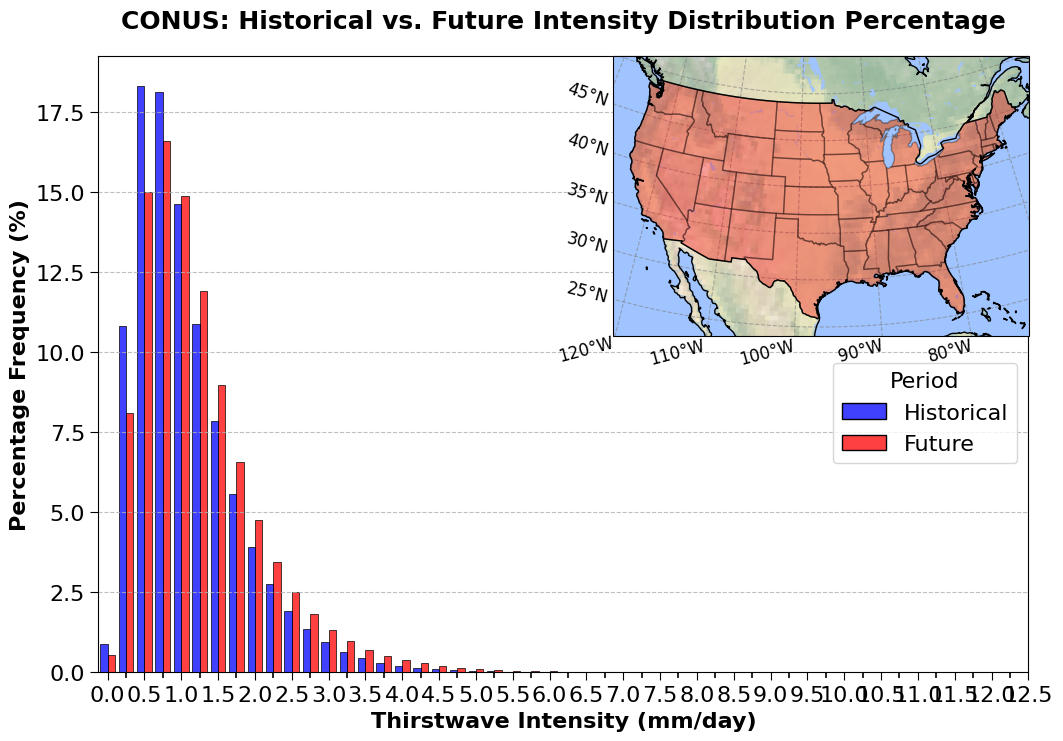

In [18]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.ticker import MultipleLocator

# Capture the figure object
fig = plt.figure(figsize=(12, 8))

# 4. Calculate maximum value and set upper limit
max_val = df_int_combined["mean_intensity"].max()
x_upper_limit = np.ceil(max_val * 2) / 2  # Round up to nearest 0.5 step

# Define explicit bin edges every 0.5 starting at 0
bin_edges = np.arange(0, x_upper_limit + 1, 0.25)

# =========================================================================
# STEP D: Histogram Plotting with Region Inset Map (Intensity)
# =========================================================================
fig = plt.figure(figsize=(12, 8))

# 4. Create the plot and capture the Axes object
ax = sns.histplot(
    data=df_int_combined,
    x="mean_intensity",
    hue="Period",
    stat="percent",
    bins=bin_edges-.125,  # Explicitly defined 0.5-wide bins
    common_norm=False,
    multiple="dodge",
    palette={"Historical": "blue", "Future": "red"},
    edgecolor="black",
    shrink=0.8,
)

# Set tick locators (Major ticks = 1.0, Minor ticks = 0.5)
ax.xaxis.set_major_locator(MultipleLocator(0.5))
ax.xaxis.set_minor_locator(MultipleLocator(0.25))

# Set tick appearance
ax.tick_params(axis="both", which="major", labelsize=16, length=6)
ax.tick_params(axis="x", which="minor", length=4, width=1.2)

# Formatting limits
plt.xlim(-0.125, x_upper_limit + 1)

plt.xlabel("Thirstwave Intensity (mm/day)", fontsize=16, fontweight="bold")
plt.ylabel("Percentage Frequency (%)", fontsize=16, fontweight="bold")
plt.title(
    "CONUS: Historical vs. Future Intensity Distribution Percentage",
    fontsize=18,
    fontweight="bold",
    pad=20,
)
plt.grid(axis="y", linestyle="--", alpha=0.8)

# =========================================================================
# MOVE LEGEND
# =========================================================================
sns.move_legend(
    ax,
    loc="upper right",
    bbox_to_anchor=(1, 0.52),
    fontsize=16,
    title_fontsize=16,
    frameon=True,
)

# =========================================================================
# ADD CONUS MAP INSET
# =========================================================================
map_crs = ccrs.LambertConformal(central_longitude=-97, central_latitude=40)

ax_inset = fig.add_axes([0.552, 0.53, 0.35, 0.35], projection=map_crs, zorder=5)

# Set spatial boundaries
ax_inset.set_extent([-121, -73, 24, 52], crs=ccrs.PlateCarree())

# Base Stock Image & Water Features
ax_inset.stock_img()
ax_inset.add_feature(
    cfeature.OCEAN.with_scale("50m"), facecolor="#a0c4ff", zorder=2
)
ax_inset.add_feature(
    cfeature.LAKES.with_scale("50m"), facecolor="#a0c4ff", zorder=2
)

# Load administrative boundaries and filter strictly for US CONUS states
shpfilename = shpreader.natural_earth(
    resolution="50m", category="cultural", name="admin_1_states_provinces_lakes"
)
reader = shpreader.Reader(shpfilename)

conus_geometries = [
    state.geometry
    for state in reader.records()
    if state.attributes["admin"] == "United States of America"
    and state.attributes["postal"]
    not in ["AK", "HI", "PR", "VI", "GU", "MP", "AS"]
]

# Add red fill ONLY to CONUS states
ax_inset.add_geometries(
    conus_geometries,
    crs=ccrs.PlateCarree(),
    facecolor="red",
    edgecolor="black",
    linewidth=1,
    alpha=0.35,
    zorder=3,
)

# Country Boundaries & Coastlines
countries = cfeature.NaturalEarthFeature(
    category="cultural",
    name="admin_0_boundary_lines_land",
    scale="50m",
    facecolor="none",
    edgecolor="black",
    linewidth=1,
    zorder=4,
)
ax_inset.add_feature(countries)

ax_inset.add_feature(
    cfeature.COASTLINE.with_scale("50m"),
    edgecolor="black",
    linewidth=1,
    zorder=4,
)

# Gridlines
gl = ax_inset.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=False,
    linewidth=0.8,
    color="gray",
    alpha=0.6,
    linestyle="--",
    zorder=5,
)

gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = True
gl.left_labels = True

gl.x_inline = False
gl.y_inline = False

gl.xpadding = 4
gl.ypadding = 4

gl.xlabel_style = {"size": 12, "color": "black", "rotation": 15}
gl.ylabel_style = {"size": 12, "color": "black"}

gl.xlocator = mticker.FixedLocator(range(-130, -60, 10))
gl.ylocator = mticker.FixedLocator(range(20, 55, 5))

plt.savefig("intensity_CONUS_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

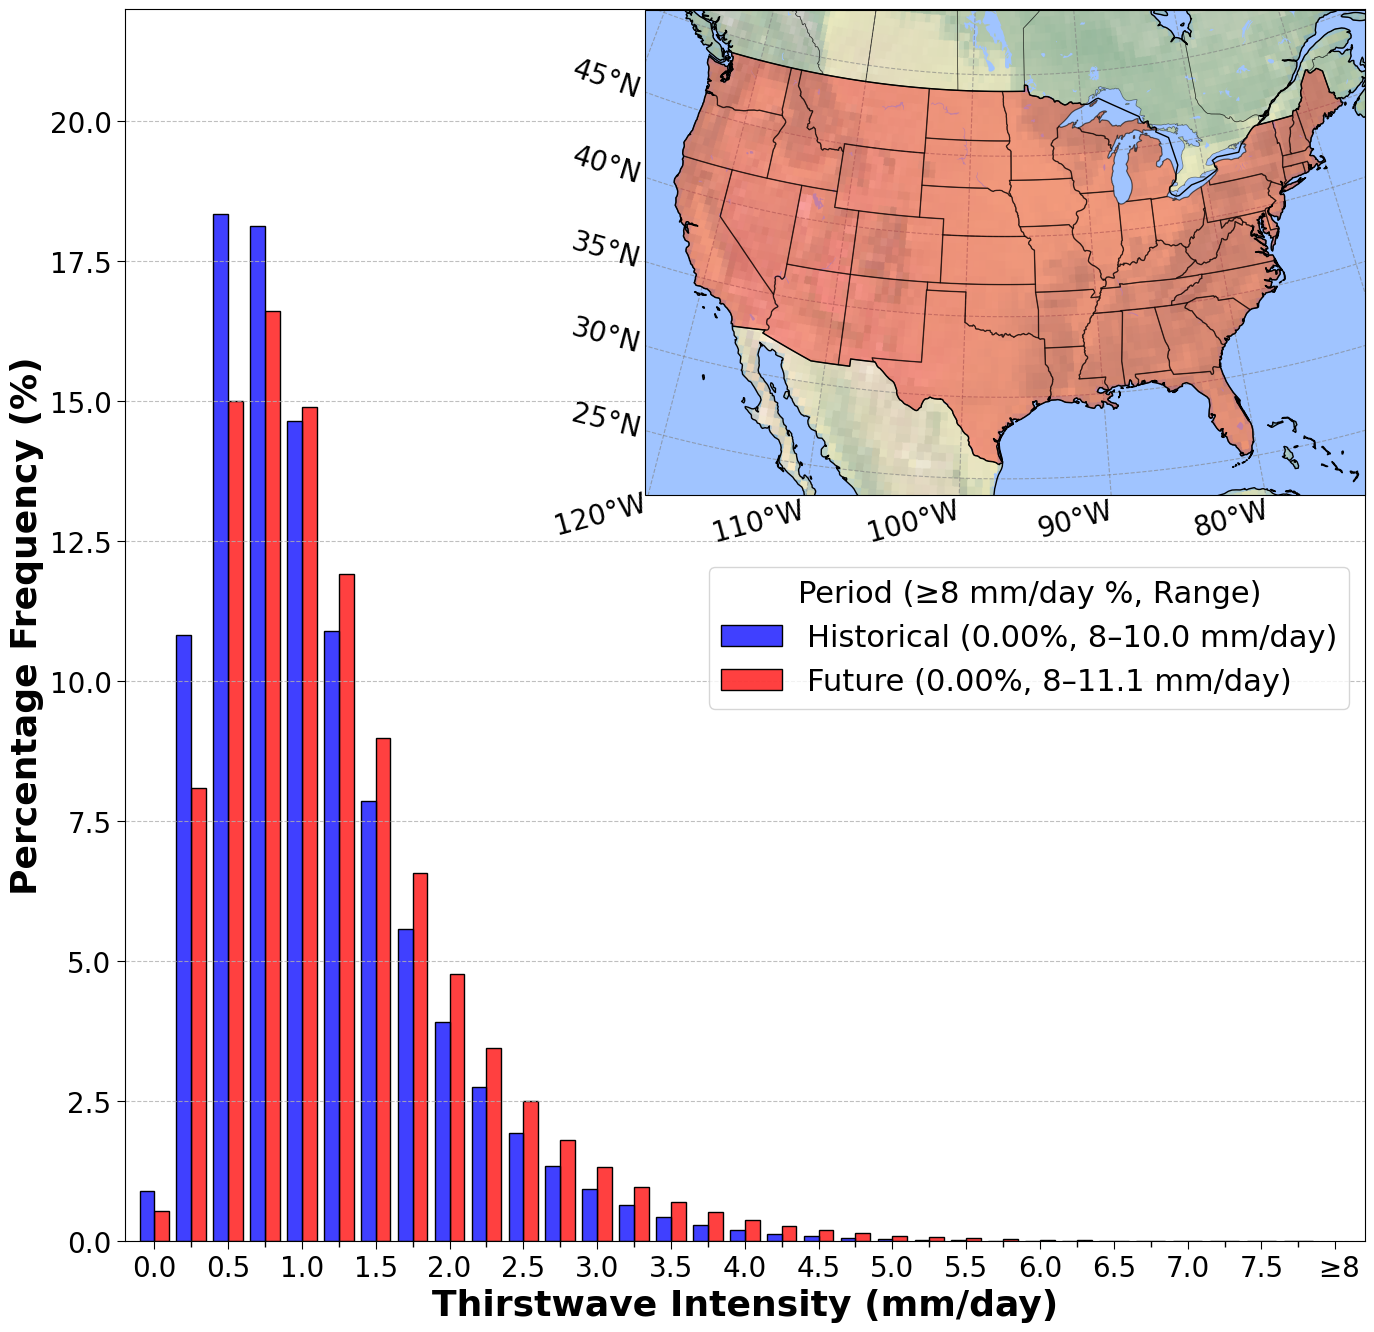

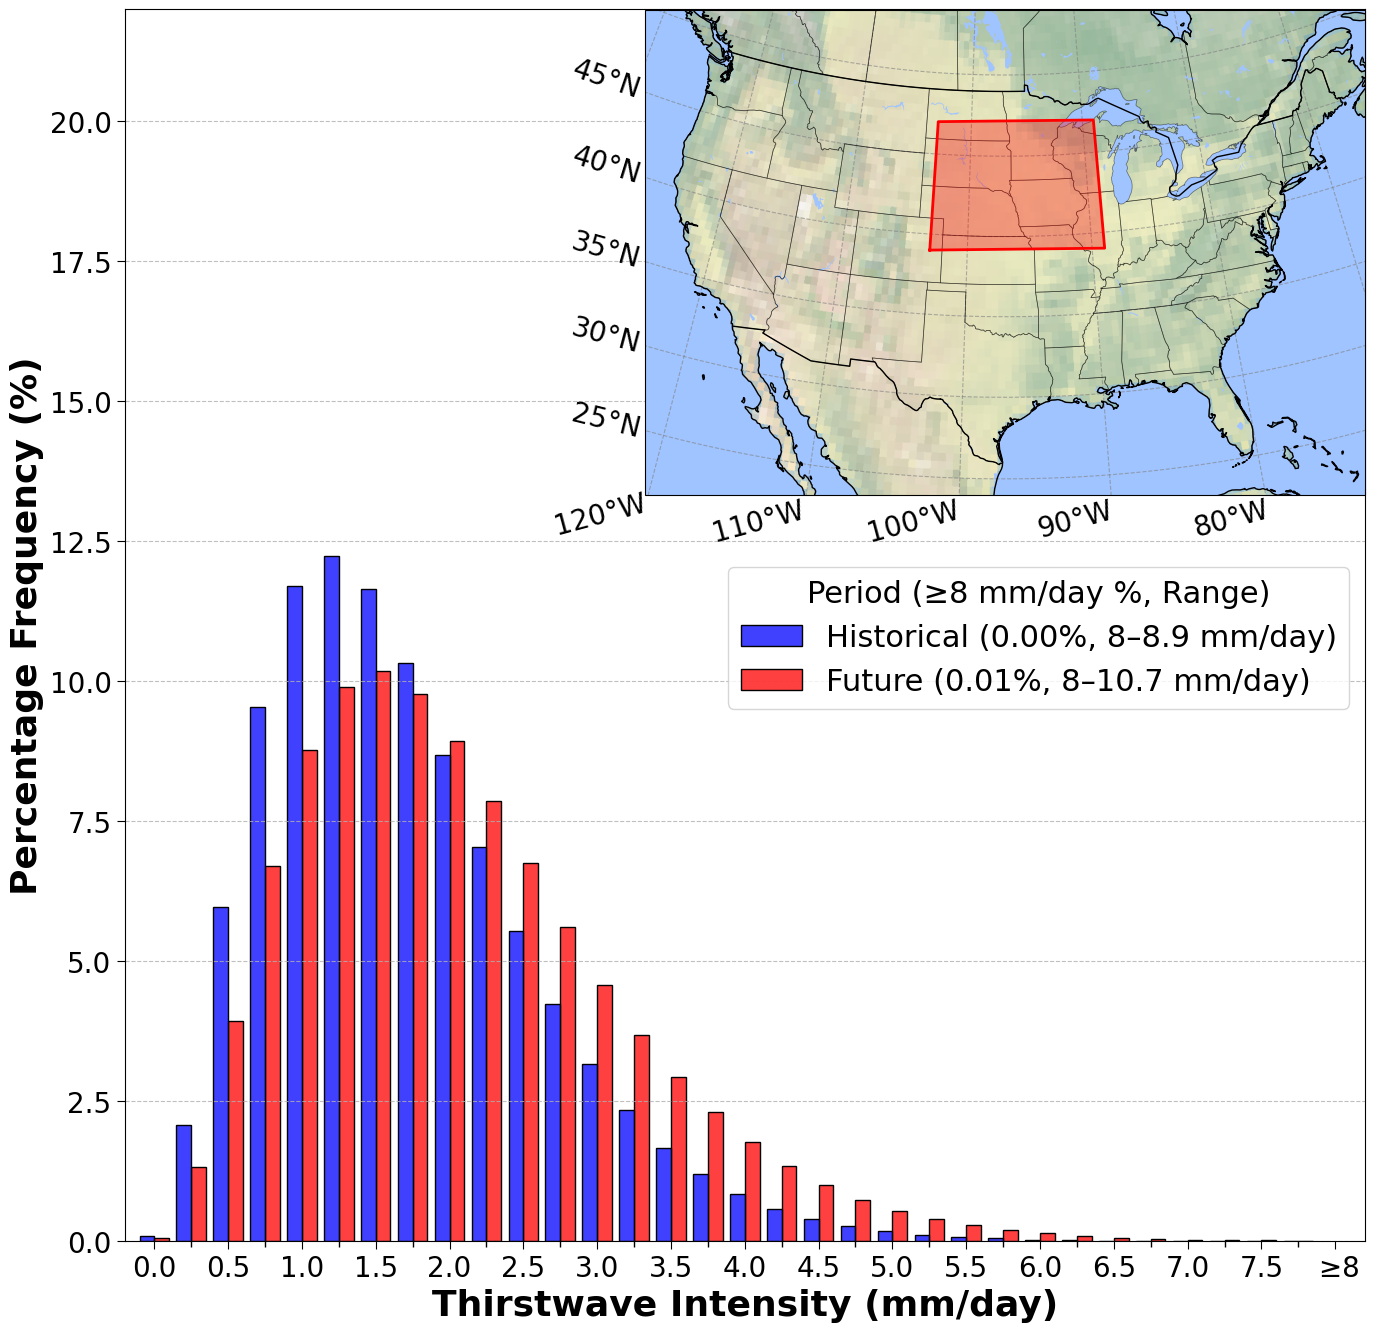

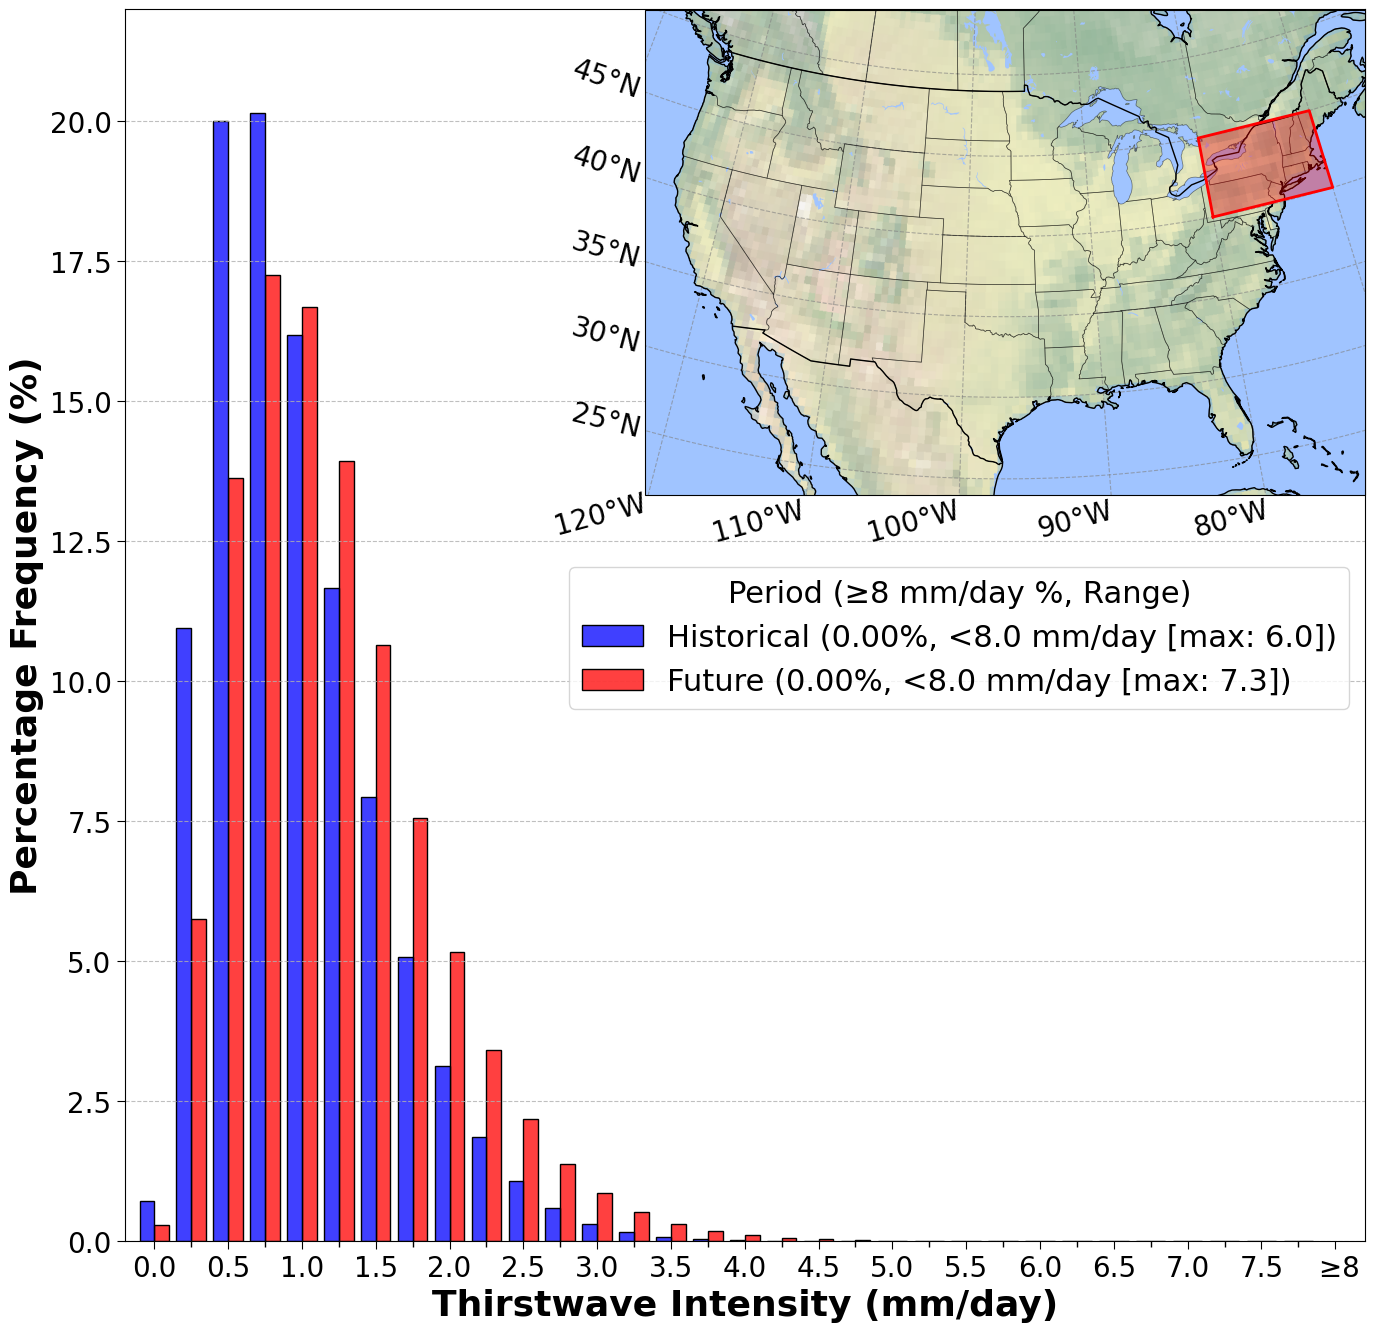

In [19]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import MultipleLocator
import numpy as np
import pandas as pd
import seaborn as sns

# =========================================================================
# 1. DEFINE REGIONS CONFIGURATION
# =========================================================================
regions = [
    {
        "name": "CONUS",
        "save_name": "intensity_CONUS_distribution.png",
        "title": "CONUS: Historical vs. Future Intensity Distribution Percentage",
        "is_conus": True,
        "lat_s": None,
        "lat_n": None,
        "lon_w": None,
        "lon_e": None,
    },
    {
        "name": "Midwest",
        "save_name": "intensity_MIDWEST_distribution.png",
        "title": "Midwest: Historical vs. Future Intensity Distribution Percentage",
        "is_conus": False,
        "lat_s": 39,
        "lat_n": 47,
        "lon_w": -103,
        "lon_e": -89,
    },
    {
        "name": "Northeast",
        "save_name": "intensity_NE_distribution.png",
        "title": "Northeast: Historical vs. Future Intensity Distribution Percentage",
        "is_conus": False,
        "lat_s": 40,
        "lat_n": 45,
        "lon_w": -80,
        "lon_e": -70,
    },
]


def slice_spatial_box(df, s=None, n=None, w=None, e=None):
    """Filter dataframe by latitude and longitude bounds.

    Returns full DataFrame if bounds are None (e.g. for CONUS).
    """
    if s is None or n is None or w is None or e is None:
        return df.copy()

    w_neg, e_neg = -abs(w), -abs(e)
    w_360, e_360 = w_neg % 360, e_neg % 360

    lat_mask = (df["lat"] >= s) & (df["lat"] <= n)
    lon_mask = ((df["lon"] >= w_neg) & (df["lon"] <= e_neg)) | (
        (df["lon"] >= w_360) & (df["lon"] <= e_360)
    )

    return df[lat_mask & lon_mask].copy()


# =========================================================================
# 2. PRE-PROCESS DATA & CALCULATE GLOBAL Y-AXIS LIMITS
# =========================================================================
processed_regions = []
global_max_y = 0

# Cache CONUS geometry once for the CONUS inset map
shpfilename = shpreader.natural_earth(
    resolution="50m", category="cultural", name="admin_1_states_provinces_lakes"
)
reader = shpreader.Reader(shpfilename)
conus_geometries = [
    state.geometry
    for state in reader.records()
    if state.attributes["admin"] == "United States of America"
    and state.attributes["postal"]
    not in ["AK", "HI", "PR", "VI", "GU", "MP", "AS"]
]

# Standardized bin edges with 0.25 mm/day resolution up to 8.0 mm/day
bin_edges = np.arange(0, 8.25, 0.25)

for reg in regions:
    # Slice data for the region (or return full set if CONUS)
    df_hist = slice_spatial_box(
        df_int_hist_conus, reg["lat_s"], reg["lat_n"], reg["lon_w"], reg["lon_e"]
    )
    df_ftr = slice_spatial_box(
        df_int_ftr_conus, reg["lat_s"], reg["lat_n"], reg["lon_w"], reg["lon_e"]
    )

    df_hist["Period"] = "Historical"
    df_ftr["Period"] = "Future"
    df_combined = pd.concat([df_hist, df_ftr], ignore_index=True)

    # Capping at 8.0 mm/day for overflow bin
    df_combined["intensity_capped"] = np.minimum(df_combined["mean_intensity"], 8.0)

    # Calculate statistics for >= 8.0 mm/day overflow bin per period
    stats = {}
    for period in ["Historical", "Future"]:
        sub_df = df_combined[df_combined["Period"] == period]
        total_count = len(sub_df)

        if total_count > 0:
            ge_8_count = len(sub_df[sub_df["mean_intensity"] >= 8.0])
            pct_ge_8 = (ge_8_count / total_count) * 100
            max_val = sub_df["mean_intensity"].max()

            # Check if region maximum reaches 8.0 mm/day
            if max_val >= 8.0:
                range_str = f"8–{max_val:.1f} mm/day"
            else:
                range_str = f"<8.0 mm/day [max: {max_val:.1f}]"

            stats[period] = {
                "pct": pct_ge_8,
                "max": max_val,
                "label": f"{period} ({pct_ge_8:.2f}%, {range_str})",
            }
        else:
            stats[period] = {
                "pct": 0.0,
                "max": 0.0,
                "label": f"{period} (0.00%, <8.0 mm/day)",
            }

    # Determine maximum percentage height across all binned bars
    for period in ["Historical", "Future"]:
        sub_data = df_combined[df_combined["Period"] == period]["intensity_capped"]
        if len(sub_data) > 0:
            counts, _ = np.histogram(sub_data, bins=bin_edges)
            percentages = (counts / len(sub_data)) * 100
            if len(percentages) > 0:
                global_max_y = max(global_max_y, percentages.max())

    processed_regions.append(
        {**reg, "df_combined": df_combined, "stats": stats}
    )

# Calculate standardized percentage boundaries matching duration and frequency scripts
y_upper_limit = (np.ceil(global_max_y / 5) * 5 + 2) - 5


# =========================================================================
# 3. GENERATE ALL INTENSITY PLOTS IN LOOP
# =========================================================================
for reg in processed_regions:
    df_comb = reg["df_combined"]
    stats = reg["stats"]

    # Map dynamic descriptive labels into DataFrame for legend construction
    df_comb["Period_Label"] = df_comb["Period"].map(
        {
            "Historical": stats["Historical"]["label"],
            "Future": stats["Future"]["label"],
        }
    )

    fig = plt.figure(figsize=(16, 16))

    palette_dict = {
        stats["Historical"]["label"]: "blue",
        stats["Future"]["label"]: "red",
    }

    # --- Histogram Plot ---
    ax = sns.histplot(
        data=df_comb,
        x="intensity_capped",
        hue="Period_Label",
        stat="percent",
        bins=bin_edges - .125,
        common_norm=False,
        multiple="dodge",
        palette=palette_dict,
        edgecolor="black",
        shrink=0.8,
    )

    # Ticks every 1.0 mm/day up to 8.0
    major_ticks = np.arange(0, 9, 0.5)

    # Replace '8' tick label with '≥8'
    tick_labels = [str(t) if t < 8 else " ≥8" for t in major_ticks]

    ax.set_xticks(major_ticks)
    ax.set_xticklabels(tick_labels)

    # Minor tick every 0.25 mm/day
    ax.xaxis.set_minor_locator(MultipleLocator(0.25))

    ax.tick_params(axis="both", which="major", labelsize=20, length=6)
    ax.tick_params(axis="x", which="minor", length=4, width=1.0)

    # X-limits locked from -0.2 to 8.2
    plt.xlim(-0.2, 8.2)
    plt.ylim(0, y_upper_limit)

    # Labels and Grid
    plt.xlabel("Thirstwave Intensity (mm/day)", fontsize=26, fontweight="bold")
    plt.ylabel("Percentage Frequency (%)", fontsize=26, fontweight="bold")
    plt.grid(axis="y", linestyle="--", alpha=0.8)

    # Move Legend
    sns.move_legend(
        ax,
        loc="upper right",
        bbox_to_anchor=(1, 0.56),
        fontsize=22,
        title="Period (≥8 mm/day %, Range)",
        title_fontsize=22,
        frameon=True,
    )

    # --- Add Cartopy Inset Map ---
    map_crs = ccrs.LambertConformal(central_longitude=-97, central_latitude=40)
    ax_inset = fig.add_axes(
        [0.45, 0.503, 0.45, 0.45], projection=map_crs, zorder=5
    )
    ax_inset.set_extent([-121, -73, 24, 52], crs=ccrs.PlateCarree())

    ax_inset.stock_img()
    ax_inset.add_feature(
        cfeature.OCEAN.with_scale("50m"), facecolor="#a0c4ff", zorder=2
    )
    ax_inset.add_feature(
        cfeature.LAKES.with_scale("50m"), facecolor="#a0c4ff", zorder=2
    )

    # Handle inset map highlight: Entire CONUS red vs. Regional Box
    if reg["is_conus"]:
        ax_inset.add_geometries(
            conus_geometries,
            crs=ccrs.PlateCarree(),
            facecolor="red",
            edgecolor="black",
            linewidth=1,
            alpha=0.35,
            zorder=3,
        )
    else:
        box_lons = [
            reg["lon_w"],
            reg["lon_e"],
            reg["lon_e"],
            reg["lon_w"],
            reg["lon_w"],
        ]
        box_lats = [
            reg["lat_s"],
            reg["lat_s"],
            reg["lat_n"],
            reg["lat_n"],
            reg["lat_s"],
        ]

        ax_inset.fill(
            box_lons,
            box_lats,
            color="red",
            alpha=0.35,
            transform=ccrs.PlateCarree(),
            zorder=6,
        )
        ax_inset.plot(
            box_lons,
            box_lats,
            color="red",
            linewidth=2,
            linestyle="-",
            transform=ccrs.PlateCarree(),
            zorder=7,
        )

    # Cartopy Boundaries & Features
    all_states = cfeature.NaturalEarthFeature(
        category="cultural",
        name="admin_1_states_provinces_lakes",
        scale="50m",
        facecolor="none",
        edgecolor="black",
        linewidth=0.5,
        alpha=0.5,
        zorder=3,
    )
    ax_inset.add_feature(all_states)

    countries = cfeature.NaturalEarthFeature(
        category="cultural",
        name="admin_0_boundary_lines_land",
        scale="50m",
        facecolor="none",
        edgecolor="black",
        linewidth=1,
        zorder=4,
    )
    ax_inset.add_feature(countries)
    ax_inset.add_feature(
        cfeature.COASTLINE.with_scale("50m"),
        edgecolor="black",
        linewidth=1,
        zorder=4,
    )

    gl = ax_inset.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=False,
        linewidth=0.8,
        color="gray",
        alpha=0.6,
        linestyle="--",
        zorder=5,
    )

    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = True
    gl.left_labels = True
    gl.x_inline = False
    gl.y_inline = False
    gl.xpadding = 4
    gl.ypadding = 4
    gl.xlabel_style = {"size": 20, "color": "black", "rotation": 15}
    gl.ylabel_style = {"size": 20, "color": "black"}
    gl.xlocator = mticker.FixedLocator(range(-130, -60, 10))
    gl.ylocator = mticker.FixedLocator(range(20, 55, 5))

    plt.savefig(reg["save_name"], dpi=300, bbox_inches="tight")
    plt.show()